# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [126]:
# importar librerías
import pandas as pd


In [127]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [128]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [129]:
orders.nunique().sort_values()

dispositivo               2
fuente_referencia         3
categoria_producto        3
monto_descuento           4
pais                      6
cantidad                  6
nombre_producto           7
fecha_hora_pedido       181
id_usuario             7642
precio_unitario       19543
monto_total           21536
id_pedido             25000
dtype: int64

In [130]:
orders.isna().mean().sort_values(ascending=False)

pais                  0.011952
categoria_producto    0.003187
cantidad              0.001992
precio_unitario       0.001992
monto_descuento       0.001992
fuente_referencia     0.001195
nombre_producto       0.001195
dispositivo           0.000797
id_pedido             0.000000
id_usuario            0.000000
fecha_hora_pedido     0.000000
monto_total           0.000000
dtype: float64

In [131]:
orders.head()


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [132]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [133]:
catalog.nunique().sort_values()

categoria_producto    3
nombre_producto       7
costo_unitario        7
proveedor             7
dtype: int64

In [134]:
catalog.isna().mean().sort_values(ascending=False)

nombre_producto       0.0
categoria_producto    0.0
costo_unitario        0.0
proveedor             0.0
dtype: float64

In [135]:
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [136]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [137]:
marketing.nunique().sort_values()

pais             3
canal            3
id_campaña       9
fecha          180
gasto         1612
dtype: int64

In [138]:
marketing.isna().mean().sort_values(ascending=False)

canal         0.062346
fecha         0.000000
pais          0.000000
id_campaña    0.000000
gasto         0.000000
dtype: float64

In [139]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [140]:
orders_clean = orders.copy()
catalog_clean = catalog.copy()
marketing_clean = marketing.copy()

In [141]:
orders_clean['fecha_hora_pedido']= pd.to_datetime(orders_clean['fecha_hora_pedido'],errors='coerce',utc=True)
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id_pedido           25100 non-null  object             
 1   id_usuario          25100 non-null  object             
 2   fecha_hora_pedido   25100 non-null  datetime64[ns, UTC]
 3   pais                24800 non-null  object             
 4   dispositivo         25080 non-null  object             
 5   fuente_referencia   25070 non-null  object             
 6   nombre_producto     25070 non-null  object             
 7   categoria_producto  25020 non-null  object             
 8   cantidad            25050 non-null  float64            
 9   precio_unitario     25050 non-null  float64            
 10  monto_descuento     25050 non-null  float64            
 11  monto_total         25100 non-null  float64            
dtypes: datetime64[ns, UTC](1), float

In [142]:
marketing_clean['fecha']= pd.to_datetime(marketing_clean['fecha'],errors='coerce',utc=True)
marketing_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   fecha       1620 non-null   datetime64[ns, UTC]
 1   pais        1620 non-null   object             
 2   id_campaña  1620 non-null   object             
 3   canal       1519 non-null   object             
 4   gasto       1620 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 63.4+ KB


In [143]:
print("=== ORDERS ===")
print(orders_clean.isnull().sum())

print("\n=== MARKETING ===")
print(marketing_clean.isnull().sum())

print("\n=== CATALOG ===")
print(catalog_clean.isnull().sum())

=== ORDERS ===
id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

=== MARKETING ===
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

=== CATALOG ===
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64


In [144]:
# Orders
orders_nan = orders_clean[orders_clean.isnull().any(axis=1)]
print(f"Filas con NaN en Orders: {len(orders_nan)}")
print(orders_nan)

# Marketing
marketing_nan = marketing_clean[marketing_clean.isnull().any(axis=1)]
print(f"\nFilas con NaN en Marketing: {len(marketing_nan)}")
print(marketing_nan)


Filas con NaN en Orders: 400
     id_pedido id_usuario         fecha_hora_pedido       pais dispositivo  \
24    order_24   user_458 2025-01-05 00:00:00+00:00   Colombia         NaN   
25    order_25   user_540 2025-03-08 00:00:00+00:00  Argentina         NaN   
26    order_26  user_1951 2025-02-10 00:00:00+00:00   Colombia         NaN   
27    order_27  user_5410 2025-05-09 00:00:00+00:00   colombia         NaN   
28    order_28  user_1489 2025-01-17 00:00:00+00:00     Mexico         NaN   
..         ...        ...                       ...        ...         ...   
419  order_419  user_3429 2025-04-06 00:00:00+00:00        NaN      mobile   
420  order_420  user_2674 2025-01-22 00:00:00+00:00        NaN     desktop   
421  order_421  user_2248 2025-01-22 00:00:00+00:00        NaN      mobile   
422  order_422  user_5872 2025-05-13 00:00:00+00:00        NaN      mobile   
423  order_423  user_5025 2025-05-30 00:00:00+00:00        NaN      mobile   

    fuente_referencia    nombre_pr

In [145]:
num_cols = ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']

nan_numericos = orders_clean[orders_clean[num_cols].isnull().any(axis=1)]
print(f"Filas con NaN en columnas numéricas: {len(nan_numericos)}")
print(nan_numericos[['id_pedido'] + num_cols])

Filas con NaN en columnas numéricas: 50
     id_pedido  cantidad  precio_unitario  monto_descuento  monto_total
74    order_74       NaN              NaN              NaN       595.85
75    order_75       NaN              NaN              NaN       458.15
76    order_76       NaN              NaN              NaN       319.75
77    order_77       NaN              NaN              NaN       227.55
78    order_78       NaN              NaN              NaN       432.39
79    order_79       NaN              NaN              NaN       527.15
80    order_80       NaN              NaN              NaN       711.18
81    order_81       NaN              NaN              NaN        41.08
82    order_82       NaN              NaN              NaN       431.55
83    order_83       NaN              NaN              NaN       279.35
84    order_84       NaN              NaN              NaN       785.89
85    order_85       NaN              NaN              NaN       576.13
86    order_86       NaN

### OBSERVACIÓN
- Las 50 filas tienen cantidad, precio_unitario y monto_descuento = NaN juntos
- Pero monto_total está completo en todas — tienen valor válido
- No se solapan con NaN en nombre_producto — son pedidos identificables
- Son filas consecutivas (order_74 a order_123) — Parece ser error de carga/importación

In [146]:
print(f"Filas antes: {len(orders_clean)}")

orders_clean = orders_clean.dropna(subset=['cantidad', 'precio_unitario', 'monto_descuento'])

# Después
print(f"Filas después: {len(orders_clean)}")

Filas antes: 25100
Filas después: 25050


In [147]:
num_cols = ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']
print(orders_clean[num_cols].isnull().sum())

cantidad           0
precio_unitario    0
monto_descuento    0
monto_total        0
dtype: int64


In [148]:
print(f"Negativos en orders_clean: {(orders_clean['cantidad'] < 0).sum()}")
print(f"Negativos en orders original: {(orders['cantidad'] < 0).sum()}")
# 2. Eliminar negativos y outliers en cantidad
orders_clean = orders_clean[orders_clean['cantidad'] > 0].reset_index(drop=True)
orders_clean = orders_clean[orders_clean['cantidad'] <= 1000].reset_index(drop=True)


Negativos en orders_clean: 4
Negativos en orders original: 4


In [149]:
print(f"Total filas orders_clean: {len(orders_clean)}")
print(f"Cantidad máxima: {orders_clean['cantidad'].max()}")
print(f"Outliers (>1000): {(orders_clean['cantidad'] > 1000).sum()}")
print(f"Negativos: {(orders_clean['cantidad'] < 0).sum()}")
print()
print(orders_clean['cantidad'].describe())

Total filas orders_clean: 25036
Cantidad máxima: 2.0
Outliers (>1000): 0
Negativos: 0

count    25036.000000
mean         1.504953
std          0.499985
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: cantidad, dtype: float64


In [150]:
text_cols = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']

for col in text_cols:
    print(f"=== {col} ===")
    print(orders_clean[col].value_counts(dropna=False))
    print()

=== pais ===
Colombia     7504
Mexico       7485
Argentina    7268
mexico        863
colombia      822
argentina     798
NaN           296
Name: pais, dtype: int64

=== dispositivo ===
desktop    12724
mobile     12292
NaN           20
Name: dispositivo, dtype: int64

=== fuente_referencia ===
social         8408
organic        8308
paid_search    8290
NaN              30
Name: fuente_referencia, dtype: int64

=== nombre_producto ===
Vacuum-Pro-Black        4193
Blender-XL-Red          4192
Jacket-Winter-M         4182
Sneakers-Urban-42       4141
Laptop-Gaming-16GB      2780
Tablet-Standard-64GB    2775
Phone-Pro-128GB         2743
NaN                       30
Name: nombre_producto, dtype: int64

=== categoria_producto ===
Hogar          8385
Moda           8323
Electronica    8298
NaN              30
Name: categoria_producto, dtype: int64



In [151]:
doble_NaN = orders_clean[orders_clean['nombre_producto'].isnull() & 
                          orders_clean['categoria_producto'].isnull()]
print(f"Filas con NaN en ambas columnas: {len(doble_NaN)}")
print(doble_NaN[['id_pedido', 'nombre_producto', 'categoria_producto', 'monto_total']])

Filas con NaN en ambas columnas: 30
   id_pedido nombre_producto categoria_producto  monto_total
44  order_44             NaN                NaN       313.38
45  order_45             NaN                NaN       698.12
46  order_46             NaN                NaN       349.31
47  order_47             NaN                NaN       953.56
48  order_48             NaN                NaN       275.93
49  order_49             NaN                NaN       867.53
50  order_50             NaN                NaN       490.38
51  order_51             NaN                NaN       765.89
52  order_52             NaN                NaN       830.01
53  order_53             NaN                NaN       472.98
54  order_54             NaN                NaN        56.50
55  order_55             NaN                NaN       321.15
56  order_56             NaN                NaN       120.43
57  order_57             NaN                NaN        70.87
58  order_58             NaN                NaN  

### OBSERVACIÓN
- los 30 NaN en nombre_producto y categoria_producto son exactamente los mismos registros. Sin producto no podemos analizar ventas, márgenes ni comportamiento.

In [152]:
filas_antes = len(orders_clean)

orders_clean = orders_clean.dropna(subset=['nombre_producto']).reset_index(drop=True)

print(f"Filas eliminadas: {filas_antes - len(orders_clean)}")
print(f"Total filas orders_clean: {len(orders_clean)}")
print(f"NaN en nombre_producto: {orders_clean['nombre_producto'].isnull().sum()}")
print(f"NaN en categoria_producto: {orders_clean['categoria_producto'].isnull().sum()}")

Filas eliminadas: 30
Total filas orders_clean: 25006
NaN en nombre_producto: 0
NaN en categoria_producto: 0


In [153]:
orders_clean['pais'] = orders_clean['pais'].str.title()

print(orders_clean['pais'].value_counts(dropna=False))

Mexico       8334
Colombia     8319
Argentina    8057
NaN           296
Name: pais, dtype: int64


In [154]:
for col in ['pais', 'dispositivo', 'fuente_referencia']:
    orders_clean[col] = orders_clean[col].fillna('Unknown')

# Verificar
for col in ['pais', 'dispositivo', 'fuente_referencia']:
    print(f"{col}: {orders_clean[col].isnull().sum()} NaN restantes")

pais: 0 NaN restantes
dispositivo: 0 NaN restantes
fuente_referencia: 0 NaN restantes


In [155]:
print(orders_clean.isnull().sum())
print(f"\n Total filas limpias: {len(orders_clean)}")

id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

 Total filas limpias: 25006


In [156]:
marketing_clean['canal'] = marketing_clean['canal'].fillna(
    marketing_clean['id_campaña'].str.rsplit('_', n=1).str[0]
)

print(marketing_clean['canal'].value_counts(dropna=False))

paid_search    540
organic        540
social         540
Name: canal, dtype: int64


In [157]:
print(marketing_clean.isnull().sum())
print(f"\n Total filas marketing limpias: {len(marketing_clean)}")

fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

 Total filas marketing limpias: 1620


In [158]:
print(f"Duplicados en orders_clean: {orders_clean.duplicated().sum()}")
print(f"Duplicados en marketing: {marketing_clean.duplicated().sum()}")
print(f"Duplicados en catalog: {catalog_clean.duplicated().sum()}")

Duplicados en orders_clean: 100
Duplicados en marketing: 0
Duplicados en catalog: 0


In [159]:
duplicados = orders_clean[orders_clean.duplicated(keep=False)]
print(f"Filas duplicadas: {len(duplicados)}")
print(duplicados.sort_values('id_pedido').head(20))

Filas duplicadas: 200
         id_pedido id_usuario         fecha_hora_pedido       pais  \
24929  order_10082   user_690 2025-02-17 00:00:00+00:00  Argentina   
9988   order_10082   user_690 2025-02-17 00:00:00+00:00  Argentina   
24943  order_10709  user_6783 2025-02-16 00:00:00+00:00   Colombia   
10615  order_10709  user_6783 2025-02-16 00:00:00+00:00   Colombia   
24971  order_10829  user_7697 2025-01-23 00:00:00+00:00  Argentina   
10735  order_10829  user_7697 2025-01-23 00:00:00+00:00  Argentina   
10762  order_10856  user_1899 2025-03-18 00:00:00+00:00   Colombia   
24950  order_10856  user_1899 2025-03-18 00:00:00+00:00   Colombia   
11355  order_11449  user_1480 2025-03-21 00:00:00+00:00     Mexico   
24989  order_11449  user_1480 2025-03-21 00:00:00+00:00     Mexico   
11443  order_11537  user_3115 2025-03-08 00:00:00+00:00  Argentina   
24909  order_11537  user_3115 2025-03-08 00:00:00+00:00  Argentina   
11529  order_11623  user_2157 2025-06-25 00:00:00+00:00     Mexico  

In [160]:
filas_antes = len(orders_clean)

orders_clean = orders_clean.drop_duplicates().reset_index(drop=True)

print(f"Filas eliminadas: {filas_antes - len(orders_clean)}")
print(f"Total filas orders_clean: {len(orders_clean)}")

Filas eliminadas: 100
Total filas orders_clean: 24906


In [161]:
print(f"Duplicados restantes: {orders_clean.duplicated().sum()}")
print(f"id_pedido duplicados: {orders_clean['id_pedido'].duplicated().sum()}")
assert orders_clean.duplicated().sum() == 0
print(" Sin duplicados")

Duplicados restantes: 0
id_pedido duplicados: 0
 Sin duplicados


In [162]:
orders_clean['monto_esperado'] = (orders_clean['cantidad'] * orders_clean['precio_unitario']) - orders_clean['monto_descuento']

discrepancias = orders_clean[abs(orders_clean['monto_total'] - orders_clean['monto_esperado']) > 0.01]
print(f"Filas con discrepancia: {len(discrepancias)}")
print(discrepancias[['id_pedido', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total', 'monto_esperado']].head(10))

Filas con discrepancia: 1142
     id_pedido  cantidad  precio_unitario  monto_descuento  monto_total  \
2      order_2       2.0           102.99             10.0       195.99   
24    order_24       2.0           117.99              0.0       235.99   
35    order_35       2.0           467.34              5.0       929.69   
41    order_41       2.0            37.77             10.0        65.53   
56   order_136       2.0           211.05             15.0       407.09   
100  order_180       2.0           451.16             15.0       887.31   
181  order_261       2.0           209.33             10.0       408.65   
186  order_270       2.0           127.95              0.0       255.89   
197  order_281       2.0           100.68              0.0       201.35   
206  order_290       2.0            41.92              5.0        78.83   

     monto_esperado  
2            195.98  
24           235.98  
35           929.68  
41            65.54  
56           407.10  
100          

In [163]:
orders_clean['diferencia'] = abs(orders_clean['monto_total'] - orders_clean['monto_esperado'])
print(orders_clean['diferencia'].describe())

count    2.490600e+04
mean     2.498996e-03
std      4.329634e-03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.684342e-14
max      1.000000e-02
Name: diferencia, dtype: float64


In [164]:
orders_clean = orders_clean.drop(columns=['monto_esperado', 'diferencia'])

print(f"Columnas orders_clean: {list(orders_clean.columns)}")
print(f"\n{'='*50}")
print(" Montos consistentes — solo errores de redondeo insignificantes")

Columnas orders_clean: ['id_pedido', 'id_usuario', 'fecha_hora_pedido', 'pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']

 Montos consistentes — solo errores de redondeo insignificantes


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [165]:
# exportar datasets
orders_clean.to_csv('orders_clean.csv', index=False)
catalog_clean.to_csv('catalog_clean.csv', index=False)
marketing_clean.to_csv('marketing_clean.csv', index=False)

In [166]:
print(f" orders_clean.csv     → {len(orders_clean)} filas")
print(f" catalog_clean.csv    → {len(catalog_clean)} filas")
print(f" marketing_clean.csv  → {len(marketing_clean)} filas")

 orders_clean.csv     → 24906 filas
 catalog_clean.csv    → 7 filas
 marketing_clean.csv  → 1620 filas


---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [167]:
# Cruzamos orders con catalog para obtener el costo unitario

orders_catalog = orders_clean.merge(catalog_clean[['nombre_producto','costo_unitario']], on='nombre_producto', how='left')

In [168]:
revenue_total = orders_clean['monto_total'].sum()
costo_total = (orders_catalog['costo_unitario'] * orders_catalog['cantidad']).sum()
inversion_marketing = marketing_clean['gasto'].sum()
ganancia_bruta = revenue_total - costo_total
profit = revenue_total - costo_total  - inversion_marketing

In [169]:
print(f'KPI´S DE RENTABILIDAD')
print(f" Ingreso total (Revenue):      ${revenue_total:,.2f}")
print(f" Costo total:                  ${costo_total:,.2f}")
print(f" Ganancia Bruta:               ${ganancia_bruta:,.2f}")
print(f" Inversión en marketing:       ${inversion_marketing:,.2f}")
print(f" Profit:                       ${profit:,.2f}")
print(f" Margen de profit:             {profit/revenue_total*100:.2f}%")

KPI´S DE RENTABILIDAD
 Ingreso total (Revenue):      $9,610,018.94
 Costo total:                  $3,828,869.01
 Ganancia Bruta:               $5,781,149.93
 Inversión en marketing:       $2,871,843.53
 Profit:                       $2,909,306.40
 Margen de profit:             30.27%


In [194]:
#TICKET PROMEDIO Y CANTIDAD PROMEDIO

ticket_promedio = orders_clean['monto_total'].mean()
cantidad_promedio = orders_clean['cantidad'].mean()

#PRODUCTO MÁS VENIDO POR UNIDADES

producto_mas_vendido = orders_clean.groupby('nombre_producto')['cantidad'].sum().idxmax()
unidades_vendidas = orders_clean.groupby('nombre_producto')['cantidad'].sum().max()

#GASTO DE MARKETING POR CANAL

marketing_por_canal = marketing_clean.groupby('canal')['gasto'].sum().sort_values(ascending = False)

In [195]:
print(f" Ticket promedio por orden:    ${ticket_promedio:,.2f}")
print(f" Cantidad promedio por orden:  {cantidad_promedio:.2f} unidades")
print(f" Producto más vendido:         {producto_mas_vendido} ({unidades_vendidas:,.0f} unidades)")
print(f"\n Gasto en marketing por canal:")
for canal, gasto in marketing_por_canal.items():
    print(f"  {canal}: ${gasto:,.2f}")

 Ticket promedio por orden:    $385.85
 Cantidad promedio por orden:  1.50 unidades
 Producto más vendido:         Vacuum-Pro-Black (6,284 unidades)

 Gasto en marketing por canal:
  social: $976,818.37
  organic: $972,650.96
  paid_search: $922,374.20


### Punto de atención: 
El gasto en marketing de **\$2.87 M** está muy cerca del Profit de  **\$2.9 M** — si la inversión en marketing sube un poco, el negocio podría volverse no rentable. Vale la pena analizar el ROI por canal.

In [172]:
# Ingresos por canal desde orders_clean
ingresos_canal = orders_clean.groupby('fuente_referencia')['monto_total'].sum().reset_index()
ingresos_canal.columns = ['canal', 'ingresos']

# Gasto por canal desde marketing_clean
gasto_canal = marketing_clean.groupby('canal')['gasto'].sum().reset_index()
gasto_canal.columns = ['canal', 'gasto']

# Unir ambos
roi_df = ingresos_canal.merge(gasto_canal, on='canal')

# Calcular ROI
# ROI = (Ingresos - Gasto) / Gasto * 100
roi_df['ROI'] = ((roi_df['ingresos'] - roi_df['gasto']) / roi_df['gasto'] * 100).round(2)

roi_df = roi_df.sort_values('ROI', ascending=False).reset_index(drop=True)

print(roi_df.to_string(index=False))

      canal   ingresos     gasto    ROI
paid_search 3209280.07 922374.20 247.94
     social 3222510.32 976818.37 229.90
    organic 3178228.55 972650.96 226.76


## OBSERVACIONES
Los tres canales son muy **Rentales** con un ROI de más del 200%, existe un campaña de marketing balanceada.

In [173]:
# Calcular ingresos, costos y profit por categoría
rentabilidad_categoria = orders_catalog.groupby('categoria_producto').agg(
    ingresos    = ('monto_total', 'sum'),
    costo_total = ('costo_unitario', lambda x: (x * orders_catalog.loc[x.index, 'cantidad']).sum()),
    ordenes     = ('id_pedido', 'count')
).reset_index()

rentabilidad_categoria['profit']       = rentabilidad_categoria['ingresos'] - rentabilidad_categoria['costo_total']
rentabilidad_categoria['margen_pct']   = (rentabilidad_categoria['profit'] / rentabilidad_categoria['ingresos'] * 100).round(2)
rentabilidad_categoria = rentabilidad_categoria.sort_values('profit', ascending=False)

print(rentabilidad_categoria.to_string(index=False))

categoria_producto   ingresos  costo_total  ordenes     profit  margen_pct
             Hogar 3232626.44   1213436.96     8346 2019189.48       62.46
              Moda 3172662.10   1290543.48     8295 1882118.62       59.32
       Electronica 3204730.40   1324888.57     8265 1879841.83       58.66


### OBSERVACIONES 
Hogar es la categoría con mejor margen y mayor *profit* 

In [174]:
# Revenue por país
revenue_pais = orders_clean.groupby('pais').agg(
    ingresos = ('monto_total', 'sum'),
    ordenes  = ('id_pedido', 'count'),
    ticket_promedio = ('monto_total', 'mean')
).reset_index()

revenue_pais['ingresos_pct'] = (revenue_pais['ingresos'] / revenue_pais['ingresos'].sum() * 100).round(2)
revenue_pais = revenue_pais.sort_values('ingresos', ascending=False).reset_index(drop=True)

print(revenue_pais.to_string(index=False))


     pais   ingresos  ordenes  ticket_promedio  ingresos_pct
   Mexico 3207047.74     8308       386.019227         33.37
 Colombia 3170333.82     8280       382.890558         32.99
Argentina 3120649.33     8022       389.011385         32.47
  Unknown  111988.05      296       378.338007          1.17


### OBSERVACIONES
Los tres paises están bastante equilibrados lo que habla de una expanción regional muy balanceada. **Argentina** tiene un ticket promedio más alto, sus clientes gastan más por orden, aunque tienen menos órdenes en total.

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [175]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [176]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [177]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [178]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH cte_first_visit AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'first_visit'
),
cte_select_item AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'select_item'
),
cte_add_to_cart AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'add_to_cart'
),
cte_begin_checkout AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'begin_checkout'
),
cte_add_payment_info AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'purchase'
)
SELECT
    (SELECT COUNT(*) FROM cte_first_visit)       AS first_visit,
    (SELECT COUNT(*) FROM cte_select_item)        AS select_item,
    (SELECT COUNT(*) FROM cte_add_to_cart)        AS add_to_cart,
    (SELECT COUNT(*) FROM cte_begin_checkout)     AS begin_checkout,
    (SELECT COUNT(*) FROM cte_add_payment_info)   AS add_payment_info,
    (SELECT COUNT(*) FROM cte_purchase)           AS purchase,

    -- Conversión entre etapas consecutivas
    ROUND((SELECT COUNT(*) FROM cte_select_item)      * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),     0), 2) AS conv_visit_a_select,
    ROUND((SELECT COUNT(*) FROM cte_add_to_cart)      * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_select_item),     0), 2) AS conv_select_a_cart,
    ROUND((SELECT COUNT(*) FROM cte_begin_checkout)   * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_add_to_cart),     0), 2) AS conv_cart_a_checkout,
    ROUND((SELECT COUNT(*) FROM cte_add_payment_info) * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_begin_checkout),  0), 2) AS conv_checkout_a_payment,
    ROUND((SELECT COUNT(*) FROM cte_purchase)         * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_add_payment_info),0), 2) AS conv_payment_a_purchase,

    -- Conversión total: first_visit → purchase
    ROUND((SELECT COUNT(*) FROM cte_purchase)         * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),     0), 2) AS conv_total
'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion

,first_visit,select_item,add_to_cart,begin_checkout,add_payment_info,purchase,conv_visit_a_select,conv_select_a_cart,conv_cart_a_checkout,conv_checkout_a_payment,conv_payment_a_purchase,conv_total
0,7796,7582,7634,7208,6250,6240,97.26,100.69,94.42,86.71,99.84,80.04


### OBSERVACIONES
El mayor punto de fuga es add_payment_info — aquí se pierden 958 usuarios (13.29%) respecto a begin_checkout. Posibles causas:
- Proceso de pago largo o complicado
- Falta de métodos de pago preferidos
- Desconfianza al ingresar datos bancarios

Hay una anomalía ya que `add_to_cart` presenta más usaurios que el paso anterior `select_item`, lo que indica que hay usuarios que agregan al carrito sin haber seleccionado productos.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [179]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [180]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 5;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [181]:
query_semanas = '''
SELECT 
    u.id_usuario,
    u.fecha_registro,
    ua.fecha_actividad,
    (ua.fecha_actividad::DATE - u.fecha_registro::DATE) / 7 AS semanas_diferencia
FROM users u
JOIN user_activity ua ON u.id_usuario = ua.id_usuario
WHERE ua.activo = 1
LIMIT 10;
'''

result = pd.read_sql(query_semanas, con=engine)
result

,id_usuario,fecha_registro,fecha_actividad,semanas_diferencia
0,user_0,2025-01-29,2025-02-12,2
1,user_0,2025-01-29,2025-02-19,3
2,user_1,2025-01-07,2025-01-28,3
3,user_2,2025-03-12,2025-03-26,2
4,user_4,2025-02-27,2025-03-06,1
5,user_4,2025-02-27,2025-03-20,3
6,user_5,2025-02-05,2025-02-26,3
7,user_6,2025-01-27,2025-02-17,3
8,user_6,2025-01-27,2025-02-24,4
9,user_7,2025-05-20,2025-06-03,2


In [182]:
# Retención por cohortes
# ======================
# Identificamos la cohorte de cada cliente 
# calculamos los meses de permanencia 

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', MIN(fecha_registro)::DATE) AS cohorte_mes
    FROM users
    GROUP BY id_usuario
),
retencion AS (
    SELECT
        c.cohorte_mes,
        COUNT(DISTINCT c.id_usuario) AS clientes_iniciales,
        COUNT(DISTINCT CASE 
            WHEN (ua.fecha_actividad::DATE - c.cohorte_mes::DATE) / 7 = 1
            AND ua.activo = 1 THEN c.id_usuario END) AS retained_w1,
        COUNT(DISTINCT CASE 
            WHEN (ua.fecha_actividad::DATE - c.cohorte_mes::DATE) / 7 = 2
            AND ua.activo = 1 THEN c.id_usuario END) AS retained_w2,
        COUNT(DISTINCT CASE 
            WHEN (ua.fecha_actividad::DATE - c.cohorte_mes::DATE) / 7 = 3
            AND ua.activo = 1 THEN c.id_usuario END) AS retained_w3
    FROM cohortes c
    LEFT JOIN user_activity ua ON c.id_usuario = ua.id_usuario
    GROUP BY c.cohorte_mes
)
SELECT
    TO_CHAR(cohorte_mes, 'YYYY-MM') AS cohorte,
    clientes_iniciales,
    retained_w1,
    retained_w2,
    retained_w3,
    ROUND(retained_w1::numeric / NULLIF(clientes_iniciales, 0) * 100, 2) AS semana_1_pct,
    ROUND(retained_w2::numeric / NULLIF(clientes_iniciales, 0) * 100, 2) AS semana_2_pct,
    ROUND(retained_w3::numeric / NULLIF(clientes_iniciales, 0) * 100, 2) AS semana_3_pct
FROM retencion
ORDER BY cohorte_mes;
'''
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final



,cohorte,clientes_iniciales,retained_w1,retained_w2,retained_w3,semana_1_pct,semana_2_pct,semana_3_pct
0,2025-01,1627,133,285,444,8.17,17.52,27.29
1,2025-02,1444,149,337,495,10.32,23.34,34.28
2,2025-03,1636,162,288,480,9.90,17.60,29.34
3,2025-04,1606,143,341,458,8.90,21.23,28.52
4,2025-05,1687,172,280,457,10.20,16.60,27.09


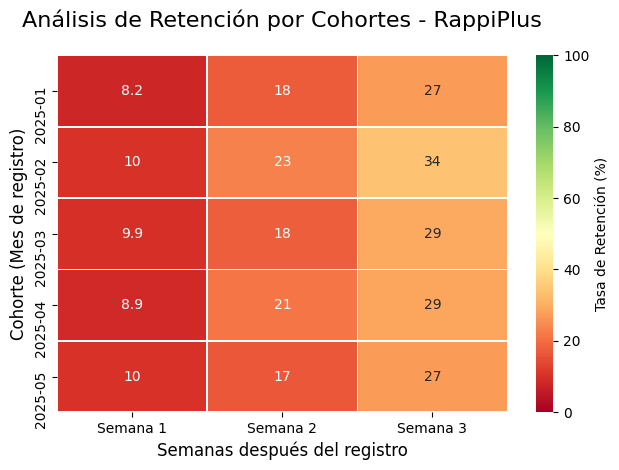

In [183]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparar datos para el heatmap

heatmap_data = cohorte_final.set_index('cohorte')[['semana_1_pct', 'semana_2_pct', 'semana_3_pct']]

# Renombrar columnas 
heatmap_data.columns = ['Semana 1', 'Semana 2', 'Semana 3']

# Crear el heatmap
sns.heatmap(heatmap_data, 
            annot=True,          
            cmap='RdYlGn',        
            center=50,            
            linewidths=0.5,       
            vmin=0, vmax=100,
            cbar_kws={'label': 'Tasa de Retención (%)'})

plt.title('Análisis de Retención por Cohortes - RappiPlus', fontsize=16, pad=20)
plt.xlabel('Semanas después del registro', fontsize=12)
plt.ylabel('Cohorte (Mes de registro)', fontsize=12)
plt.tight_layout()
plt.show()

### OBSERVACIONES
La retención crece con el tiempo — el patrón es inusual pero positivo: más usuarios están activos en semana 3 que en semana 1. Esto sugiere que los usuarios tardan en "activarse" pero una vez enganchados, siguen usando la plataforma.
La cohorte de febrero es la mejor, por lo que vale la pena analizar si se realizó alguna campaña especial ese mes. 

In [184]:
query_cohort_retention_pais ='''

WITH cohortes AS (
    SELECT
        id_usuario,
        país,
        DATE_TRUNC('month', MIN(fecha_registro)::DATE) AS cohorte_mes
    FROM users
    GROUP BY id_usuario, país
),
retencion AS (
    SELECT
        c.cohorte_mes,
        c.país,
        COUNT(DISTINCT c.id_usuario) AS clientes_iniciales,
        COUNT(DISTINCT CASE 
            WHEN (ua.fecha_actividad::DATE - c.cohorte_mes::DATE) / 7 = 1
            AND ua.activo = 1 THEN c.id_usuario END) AS retained_w1,
        COUNT(DISTINCT CASE 
            WHEN (ua.fecha_actividad::DATE - c.cohorte_mes::DATE) / 7 = 2
            AND ua.activo = 1 THEN c.id_usuario END) AS retained_w2,
        COUNT(DISTINCT CASE 
            WHEN (ua.fecha_actividad::DATE - c.cohorte_mes::DATE) / 7 = 3
            AND ua.activo = 1 THEN c.id_usuario END) AS retained_w3
    FROM cohortes c
    LEFT JOIN user_activity ua ON c.id_usuario = ua.id_usuario
    GROUP BY c.cohorte_mes, c.país
)
SELECT
    TO_CHAR(cohorte_mes, 'YYYY-MM') AS cohorte,
    país,
    clientes_iniciales,
    retained_w1,
    retained_w2,
    retained_w3,
    ROUND(retained_w1::numeric / NULLIF(clientes_iniciales, 0) * 100, 2) AS semana_1_pct,
    ROUND(retained_w2::numeric / NULLIF(clientes_iniciales, 0) * 100, 2) AS semana_2_pct,
    ROUND(retained_w3::numeric / NULLIF(clientes_iniciales, 0) * 100, 2) AS semana_3_pct
FROM retencion
ORDER BY cohorte_mes;
'''
cohorte_pais = pd.read_sql(query_cohort_retention_pais, con=engine)
cohorte_pais

,cohorte,país,clientes_iniciales,retained_w1,retained_w2,retained_w3,semana_1_pct,semana_2_pct,semana_3_pct
0,2025-01,Argentina,516,48,91,140,9.30,17.64,27.13
1,2025-01,Colombia,554,48,88,142,8.66,15.88,25.63
2,2025-01,Mexico,557,37,106,162,6.64,19.03,29.08
3,2025-02,Argentina,462,58,116,156,12.55,25.11,33.77
4,2025-02,Colombia,473,47,107,182,9.94,22.62,38.48
5,2025-02,Mexico,509,44,114,157,8.64,22.40,30.84
6,2025-03,Argentina,586,60,106,170,10.24,18.09,29.01
7,2025-03,Colombia,522,52,97,161,9.96,18.58,30.84
8,2025-03,Mexico,528,50,85,149,9.47,16.10,28.22
9,2025-04,Argentina,501,40,101,143,7.98,20.16,28.54


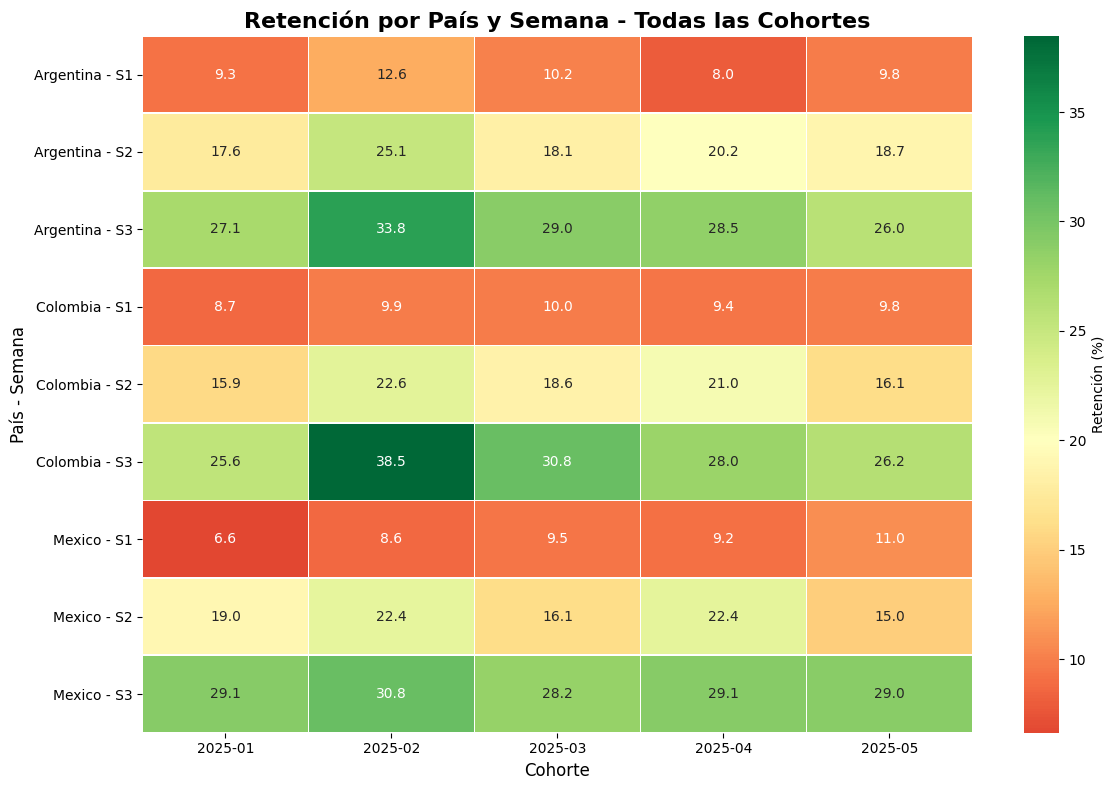

In [185]:
# Heatmap combinado - Retención por semana y país
fig, ax = plt.subplots(figsize=(12, 8))

# Preparar datos para el heatmap combinado
datos_combinados = []
for _, row in cohorte_pais.iterrows():
    for semana in [1, 2, 3]:
        datos_combinados.append({
            'país_semana': f"{row['país']} - S{semana}",
            'cohorte': row['cohorte'],
            'retención': row[f'semana_{semana}_pct']
        })

df_combinado = pd.DataFrame(datos_combinados)
pivot_combinado = df_combinado.pivot(index='país_semana', columns='cohorte', values='retención')

# Crear heatmap combinado
sns.heatmap(pivot_combinado,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=20,
            ax=ax,
            cbar_kws={'label': 'Retención (%)'},
            linewidths=0.5,
           )

ax.set_title('Retención por País y Semana - Todas las Cohortes', fontsize=16, fontweight='bold')
ax.set_xlabel('Cohorte', fontsize=12)
ax.set_ylabel('País - Semana', fontsize=12)

plt.tight_layout()
plt.show()

### OBSERVACIONES
Se muestra el mismo patrón de retención en los países con la mejor retención en la semana 3 y siendo febrero la mejor Cohorte.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):**  No hay diferencia en la tasa de conversión entre control y tratamiento
   - **H₁ (Hipótesis alternativa):** Sí hay diferencia en la tasa de conversión entre control y tratamiento
   
**Test estadístico:** Prueba Z de Proporciones
Se elige porque:
- Está diseñada para comparar proporciones en dos grupos (control vs tratamiento)
- Queremso saber si compró o no compró

**alpha = 0.05**

In [186]:
import pandas as pd
from scipy import stats

experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
print(experiment.shape)
print(experiment.dtypes)
experiment.head()

(10000, 7)
id_usuario          object
variante            object
convirtio            int64
dispositivo         object
pais                object
duracion_sesion    float64
timestamp           object
dtype: object


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [187]:
# Explorar la distribución de variantes
print("Distribución de variantes:")
print(experiment['variante'].value_counts())
print("\nPorcentaje por variante:")
print(experiment['variante'].value_counts(normalize=True) * 100)

# Calcular tasas de conversión por grupo
conversion_by_group = experiment.groupby('variante')['convirtio'].agg(['count', 'sum', 'mean'])
conversion_by_group.columns = ['total_usuarios', 'conversiones', 'tasa_conversion']
conversion_by_group['tasa_conversion_pct'] = conversion_by_group['tasa_conversion'] * 100

print("\nTasas de conversión por grupo:")
print(conversion_by_group)

Distribución de variantes:
tratamiento    5035
control        4965
Name: variante, dtype: int64

Porcentaje por variante:
tratamiento    50.35
control        49.65
Name: variante, dtype: float64

Tasas de conversión por grupo:
             total_usuarios  conversiones  tasa_conversion  \
variante                                                     
control                4965           779         0.156898   
tratamiento            5035           820         0.162860   

             tasa_conversion_pct  
variante                          
control                15.689829  
tratamiento            16.285998  


In [188]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Extraer datos para cada grupo
control_data = experiment[experiment['variante'] == 'control']
tratamiento_data = experiment[experiment['variante'] == 'tratamiento']

# Contar conversiones y totales
conversiones = [control_data['convirtio'].sum(), tratamiento_data['convirtio'].sum()]
totales = [len(control_data), len(tratamiento_data)]

print("Datos del experimento:")
print(f"Control: {conversiones[0]} conversiones de {totales[0]} usuarios")
print(f"Tratamiento: {conversiones[1]} conversiones de {totales[1]} usuarios")

# Realizar prueba z de proporciones
z_stat, p_value = proportions_ztest(conversiones, totales)

print(f"\nResultados de la prueba z:")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Datos del experimento:
Control: 779 conversiones de 4965 usuarios
Tratamiento: 820 conversiones de 5035 usuarios

Resultados de la prueba z:
Z-statistic: -0.8133
P-value: 0.4161


In [198]:
alpha = 0.05

# Calcular tasas de conversión
tasa_control = conversiones[0] / totales[0]
tasa_tratamiento = conversiones[1] / totales[1]
diferencia = tasa_tratamiento - tasa_control

print(f"\n{'='*50}")
print(f"RESULTADOS DEL EXPERIMENTO A/B")
print(f"{'='*50}")
print(f"Tasa conversión control:     {tasa_control:.4f} ({tasa_control*100:.2f}%)")
print(f"Tasa conversión tratamiento: {tasa_tratamiento:.4f} ({tasa_tratamiento*100:.2f}%)")
print(f"Diferencia absoluta:         {diferencia:.4f} ({diferencia*100:.2f} puntos porcentuales)")
print(f"Mejora relativa:             {(diferencia/tasa_control)*100:.2f}%")

print(f"\n{'='*50}")
print(f"DECISIÓN ESTADÍSTICA (α = {alpha})")
print(f"{'='*50}")

if p_value < alpha:
    print(f" p-value ({p_value:.4f}) < α ({alpha})")
    print("→ RECHAZAMOS H₀: Hay diferencia significativa")
    
    if diferencia > 0:
        print("→ RECOMENDACIÓN: IMPLEMENTAR el nuevo checkout UI")
        print("  El tratamiento mejora significativamente la conversión")
    else:
        print("→ RECOMENDACIÓN: NO implementar el cambio")
        print("  El tratamiento reduce significativamente la conversión")
else:
    print(f"\n p-value ({p_value:.4f}) ≥ α ({alpha})")
    print(f"\n{'-'*50}")
    print("→ NO RECHAZAMOS H₀: No hay diferencia significativa")
    print("→ RECOMENDACIÓN: NO implementar el cambio")
    print("  La diferencia observada puede deberse al azar")


RESULTADOS DEL EXPERIMENTO A/B
Tasa conversión control:     0.1569 (15.69%)
Tasa conversión tratamiento: 0.1629 (16.29%)
Diferencia absoluta:         0.0060 (0.60 puntos porcentuales)
Mejora relativa:             3.80%

DECISIÓN ESTADÍSTICA (α = 0.05)

 p-value (0.4161) ≥ α (0.05)

--------------------------------------------------
→ NO RECHAZAMOS H₀: No hay diferencia significativa
→ RECOMENDACIÓN: NO implementar el cambio
  La diferencia observada puede deberse al azar


### OBSERVACIONES
La diferencia que observas entre los grupos podría perfectamente deberse a la variabilidad natural de los datos, no a un efecto real del nuevo checkout UI.

**Analizaremos que debemos cambiar en nuestro experimento para observar algún cambio**

In [190]:

from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import ttest_power
import numpy as np

# Datos del experimento
p1 = 0.1569  
p2 = 0.1629  
n1 = 4965    
n2 = 5035    
alpha = 0.05

# Calculate effect size (Cohen's h for proportions)
effect_size = proportion_effectsize(p1, p2)

# For proportions, we can use a normal approximation
# Calculate pooled standard error
n_total = n1 + n2
p_pooled = (p1 * n1 + p2 * n2) / n_total
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))

# Calculate z-score for the observed difference
z_observed = abs(p2 - p1) / se_pooled

# Approximate power calculation
from scipy import stats
power_approx = 1 - stats.norm.cdf(1.96 - z_observed) + stats.norm.cdf(-1.96 - z_observed)

print("="*60)
print("ANÁLISIS DE PODER ESTADÍSTICO")
print("="*60)
print(f"Tasa de conversión control:    {p1:.4f} ({p1*100:.2f}%)")
print(f"Tasa de conversión tratamiento: {p2:.4f} ({p2*100:.2f}%)")
print(f"Diferencia observada:          {p2-p1:.4f} ({(p2-p1)*100:.2f} puntos porcentuales)")
print(f"Tamaño del efecto (Cohen's h): {effect_size:.4f}")
print(f"Tamaño de muestra por grupo:   ~{(n1+n2)/2:.0f}")
print(f"Nivel de significancia (α):    {alpha}")
print(f"\n PODER ESTADÍSTICO ESTIMADO: {power_approx:.4f} ({power_approx*100:.1f}%)")

# Interpretation
if power_approx >= 0.8:
    print(" PODER ADECUADO: Tu experimento tiene suficiente poder para detectar esta diferencia")
else:
    print(" PODER INSUFICIENTE: El experimento tiene bajo poder para detectar esta diferencia")
    print(" Esto explica por qué no se encontró significancia estadística")

ANÁLISIS DE PODER ESTADÍSTICO
Tasa de conversión control:    0.1569 (15.69%)
Tasa de conversión tratamiento: 0.1629 (16.29%)
Diferencia observada:          0.0060 (0.60 puntos porcentuales)
Tamaño del efecto (Cohen's h): -0.0164
Tamaño de muestra por grupo:   ~5000
Nivel de significancia (α):    0.05

 PODER ESTADÍSTICO ESTIMADO: 0.1296 (13.0%)
 PODER INSUFICIENTE: El experimento tiene bajo poder para detectar esta diferencia
 Esto explica por qué no se encontró significancia estadística


In [191]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_effectsize

def calcular_tamaño_muestra(p1, p2, poder=0.8, alpha=0.05):
    """
    Calcula el tamaño de muestra necesario para un test de proporciones
    
    Parámetros:
    - p1: proporción del grupo control
    - p2: proporción del grupo tratamiento  
    - poder: poder estadístico deseado (default: 0.8)
    - alpha: nivel de significancia (default: 0.05)
    """
    
    # Calcular el tamaño del efecto
    effect_size = abs(proportion_effectsize(p1, p2))
    
    # Z-scores para alpha y beta
    z_alpha = stats.norm.ppf(1 - alpha/2)  # two-tailed test
    z_beta = stats.norm.ppf(poder)
    
    # Proporción promedio
    p_avg = (p1 + p2) / 2
    
    # Fórmula para tamaño de muestra
    numerador = (z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) + 
                z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2
    
    denominador = (p2 - p1)**2
    
    n_por_grupo = numerador / denominador
    
    return int(np.ceil(n_por_grupo))

# Datos de tu experimento actual
p_control = 0.1569
p_tratamiento = 0.1629

print("="*70)
print("CÁLCULO DE TAMAÑO DE MUESTRA NECESARIO")
print("="*70)

CÁLCULO DE TAMAÑO DE MUESTRA NECESARIO


In [192]:
# Escenario 1: Para detectar la diferencia que observaste
n_necesario = calcular_tamaño_muestra(p_control, p_tratamiento, poder=0.8)

print(f" ESCENARIO 1: Detectar diferencia observada")
print("-" * 50)
print(f"   Diferencia: {(p_tratamiento - p_control)*100:.2f} puntos porcentuales")
print(f"   Muestra necesaria por grupo: {n_necesario:,} usuarios")
print(f"   Muestra total necesaria: {n_necesario*2:,} usuarios")
print(f"   Tu muestra actual: ~{5000:,} por grupo")
print(f"   Factor de incremento: {n_necesario/5000:.1f}x")

print(f"\n ESCENARIO 2: Diferentes tamaños de efecto")
print("-" * 50)

# Diferentes diferencias que podrías querer detectar
diferencias = [0.005, 0.01, 0.015, 0.02, 0.025]  # en términos absolutos

for diff in diferencias:
    p2_nuevo = p_control + diff
    n_requerido = calcular_tamaño_muestra(p_control, p2_nuevo, poder=0.8)
    mejora_relativa = (diff / p_control) * 100
    
    print(f"   Diferencia: {diff*100:.1f} pp ({mejora_relativa:.1f}% mejora) → {n_requerido:,} usuarios/grupo")

 ESCENARIO 1: Detectar diferencia observada
--------------------------------------------------
   Diferencia: 0.60 puntos porcentuales
   Muestra necesaria por grupo: 58,575 usuarios
   Muestra total necesaria: 117,150 usuarios
   Tu muestra actual: ~5,000 por grupo
   Factor de incremento: 11.7x

 ESCENARIO 2: Diferentes tamaños de efecto
--------------------------------------------------
   Diferencia: 0.5 pp (3.2% mejora) → 84,134 usuarios/grupo
   Diferencia: 1.0 pp (6.4% mejora) → 21,299 usuarios/grupo
   Diferencia: 1.5 pp (9.6% mejora) → 9,584 usuarios/grupo
   Diferencia: 2.0 pp (12.7% mejora) → 5,456 usuarios/grupo
   Diferencia: 2.5 pp (15.9% mejora) → 3,533 usuarios/grupo


 **El experimento actual estaba "subdimensionado":**

- Se necesitabas más usuarios (58,575 vs 5,000 por grupo)
Esto explica perfectamente por qué no se encontró significancia estadística

- Para detectar una mejora del 6.4% → 21,299 usuarios/grupo
- Para detectar una mejora del 12.7% → 5,456 usuarios/grupo (similar a la muestra actual)


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [193]:
# (Pega aquí tu link)
# link de power bi o tableau
# link de one drive / google drive